In [ ]:
from google.colab import files
files.upload()

In [ ]:
!unzip brain_tumor_dataset.zip

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Image size and batch size
img_size = 224
batch_size = 32

dataset_path = "/content/brain_tumor_dataset"

# Data preprocessing + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.5862 - loss: 1.1709 - val_accuracy: 0.7400 - val_loss: 0.5750
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7241 - loss: 0.5656 - val_accuracy: 0.6800 - val_loss: 0.7740
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.7143 - loss: 0.5962 - val_accuracy: 0.7200 - val_loss: 0.5846
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7734 - loss: 0.5255 - val_accuracy: 0.6600 - val_loss: 0.5598
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7094 - loss: 0.5707 - val_accuracy: 0.7600 - val_loss: 0.6189
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7685 - loss: 0.5077 - val_accuracy: 0.6600 - val_loss: 0.5918
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7882 - loss: 0.5107 - val_accuracy: 0.7200 - val_loss: 0.5509
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - a

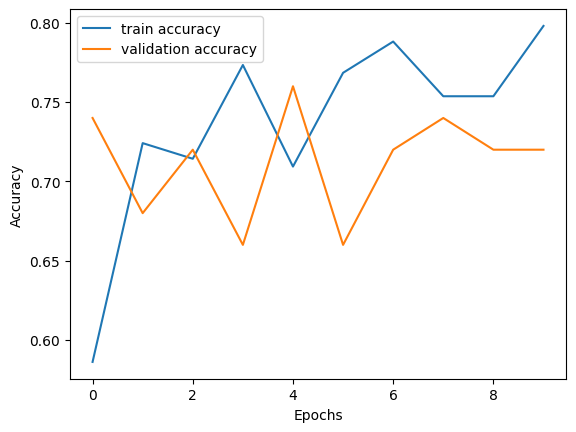

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()